## Heart Disease Prediction Model

### 1. Data Loading

First, you need to download the 'Heart Disease UCI Dataset' from Kaggle. You can find it [here](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-uci).

**Instructions to download the dataset:**
1. Go to the Kaggle dataset page.
2. Click on the 'Download' button to get the `heart.csv` file.
3. Upload the `heart.csv` file to your Colab environment by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'.

Once the `heart.csv` file is uploaded, the following code will load it into a pandas DataFrame.

In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('heart.csv')
    print("Dataset loaded successfully!")
    display(df)
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please upload the dataset to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


### 2. Data Cleaning

First, let's check for missing values and understand the data types of each column.

In [ ]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### 3. Exploratory Data Analysis (EDA)

Let's start by looking at the distribution of our target variable.

/tmp/ipykernel_5942/1725488913.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis',legend=False)


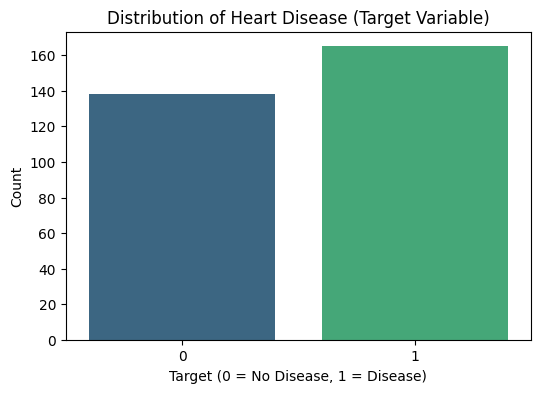

target
1    165
0    138
Name: count, dtype: int64
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis',legend=False)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

### 4. Model Training and Evaluation

Now, let's prepare the data for modeling by splitting it into features (X) and the target variable (y). Then, we will split these into training and testing sets to evaluate our model's performance on unseen data.

We will use Logistic Regression as our classification model. After training, we will evaluate its performance using accuracy, a confusion matrix, and the ROC curve with AUC score. Finally, we will look at the model coefficients to understand feature importance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)


#### Training the Logistic Regression Model

In [ ]:
# Initialize and train the Logistic Regression model with scaled data
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set using scaled data
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete.")

Model training complete.


#### Model Evaluation

Let's evaluate the model's performance using accuracy, a confusion matrix, and the ROC curve.

Accuracy: 0.8689


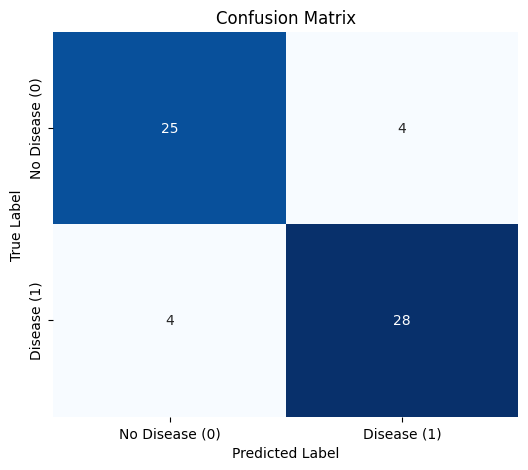

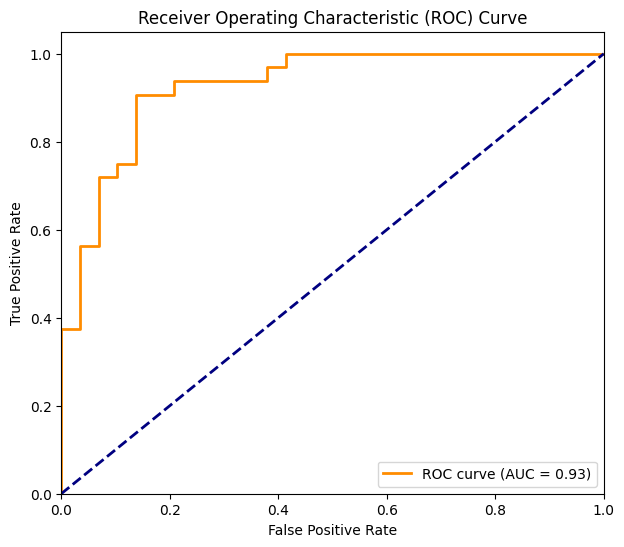

ROC AUC Score: 0.9267


In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

#### Feature Importance

For Logistic Regression, the coefficients of the features can indicate their importance in predicting the target variable. A larger absolute value of a coefficient suggests a stronger influence.

,feature,coefficient,abs_coefficient
2,cp,0.817904,0.817904
11,ca,-0.789955,0.789955
1,sex,-0.783086,0.783086
9,oldpeak,-0.681396,0.681396
12,thal,-0.565659,0.565659
8,exang,-0.517584,0.517584
10,slope,0.435302,0.435302
7,thalach,0.395131,0.395131
6,restecg,0.284179,0.284179
3,trestbps,-0.273307,0.273307


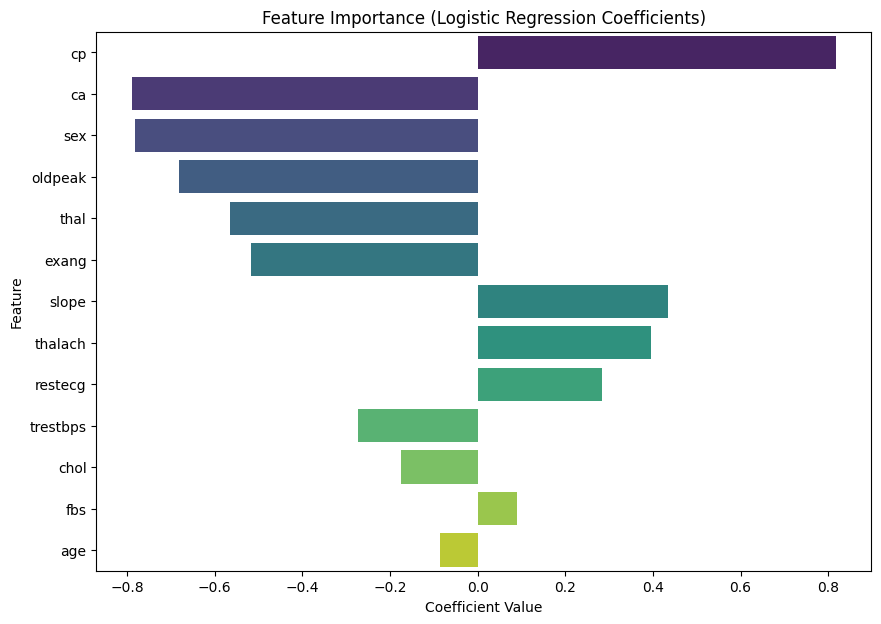

In [ ]:
# Get feature importance from coefficients
# For scaled data, coefficients directly reflect importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Sort by absolute coefficient value
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 7))
sns.barplot(x='coefficient', y='feature', data=feature_importance, palette='viridis', hue='feature', legend=False)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()